In [1]:
import xarray as xr
import matplotlib.pyplot as plt 
import seaborn as sns
import cartopy.crs as ccrs
import seaborn.objects as so
import numpy as np
from dask.distributed import LocalCluster, Client
import flox.xarray
import xesmf as xe
from affine import Affine

from tqdm.notebook import tqdm
import scipy
import dask.bag as db
from pyproj import Proj, Transformer, CRS
import geopandas as gpd
from rasterio import features
from shapely.geometry import shape

import pandas as pd
plt.style.use('robin')
from matplotlib.colors import LogNorm, Normalize
proj = ccrs.NorthPolarStereo(0,70)

def sigmoid(x):
    return 1/(1+np.exp(-x))

In [3]:
# run_id = '3w874ud3'
# run_id = '0obl1joe'
run_id = '75kakckt'
# ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_attributions.nc', chunks = dict(time_of_event=20)).load()
ds_attrs = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_ALL_attributions_v2.nc').transpose('y','x',...)
ds_moran = xr.open_dataset(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_moranI_lrp_normed_v2.nc') 
ds_attrs['moran_I'] = ds_moran.Moran_I

lrp_normed = ds_attrs.attributions_lrp 
lrp_normed = lrp_normed.sum('var_name')/lrp_normed.sum('var_name').clip(0).sum(['x','y'])
ds_attrs['lrp_normed'] = lrp_normed

# ig_normed = ds_attrs.attributions_ig 
# ig_normed = ig_normed/ig_normed.sum('var_name').max(['x','y'])
# # cycs = cycs.query("msl<100000")
gdf_cyclones = gpd.read_file(f'/Data/gfi/users/rogui7909/data/NN_outputs/attributions/newproj/{run_id}_cyclones_data.geojson')

# Plot 1: attributions are aggregated

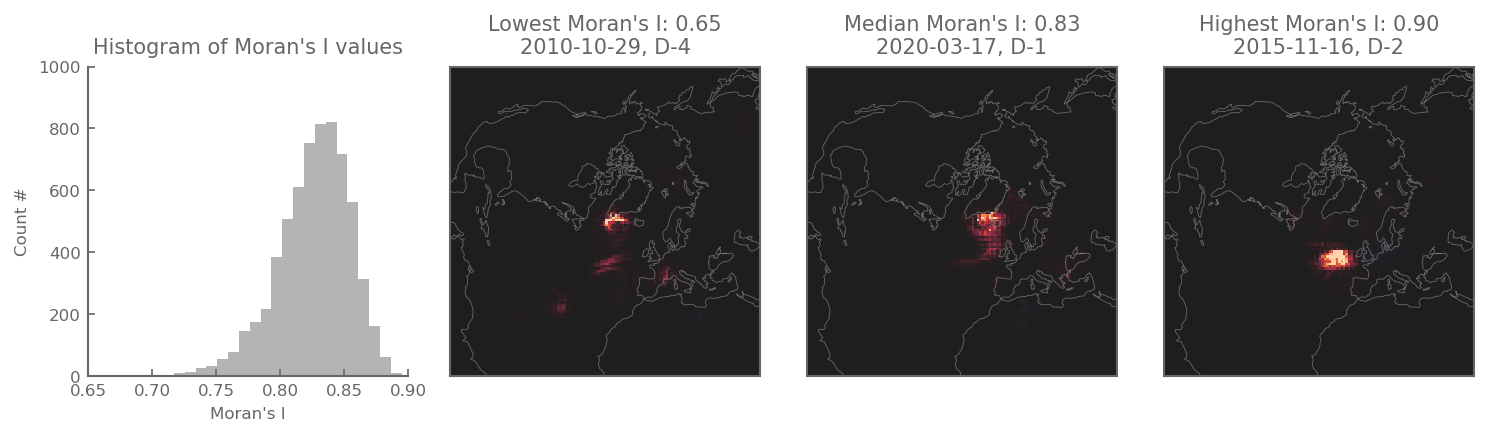

In [7]:
# print(ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past']).idxmax().values)
# print(ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past']).idxmin().values)
fig, axs = plt.subplot_mosaic("""ABCD""", figsize=(10,2.8), 
                              per_subplot_kw=dict(BCD=dict(projection=proj)))
ds_attrs.moran_I.stack(sample=['time_of_event','timestep_past']).idxmax()

ds_attrs.moran_I.plot.hist(ax=axs['A'], bins=30, color='.7')
ds_attrs.sel(time_of_event='2010-10-29', timestep_past=-4).lrp_normed.plot(ax=axs['B'], transform=proj, add_colorbar=False, cmap='icefire', vmax=.008)
ds_attrs.sel(time_of_event='2020-03-17', timestep_past=-1).lrp_normed.plot(ax=axs['C'], transform=proj, add_colorbar=False, cmap='icefire', vmax=.008)
ds_attrs.sel(time_of_event='2015-11-16', timestep_past=-2).lrp_normed.plot(ax=axs['D'], transform=proj, add_colorbar=False, cmap='icefire', vmax=.008)


lowest_moran = ds_attrs.sel(time_of_event='2010-10-29', timestep_past=-4).moran_I.values
median_moran = ds_attrs.sel(time_of_event='2020-03-17', timestep_past=-1).moran_I.values
highest_moran = ds_attrs.sel(time_of_event='2015-11-16', timestep_past=-2).moran_I.values

for letter in 'BCD':
    axs[letter].coastlines(color='.7', lw=.4, alpha=.5)
axs['A'].set_title('Histogram of Moran\'s I values')
axs['A'].set(xlabel="Moran's I", ylabel='Count #', xlim=(.65,.9), ylim=(0,1000))
axs['B'].set_title(f'Lowest Moran\'s I: {lowest_moran:.02f}\n2010-10-29, D-4')
axs['C'].set_title(f'Median Moran\'s I: {median_moran:.02f}\n2020-03-17, D-1')
axs['D'].set_title(f'Highest Moran\'s I: {highest_moran:.02f}\n2015-11-16, D-2')
plt.tight_layout()
# plt.savefig('plots/moranI_examples_lrp_normed_v2.svg', dpi=300)

# Plot 2: example to get to blobs and cyclones

In [8]:
gdf_cyclones

,cyclones,date,time_of_event,blob_attributions,timestep_past,blob_area,blob_category,key,cyclone_msl,cyclone_lon,cyclone_lat,cyclone_x,cyclone_y,cyclone_region,geometry
0,0.0,1979-01-02,1979-01-07,0.133534,-5,1.605536e+06,large positive,1979-01-02 0.0,100748.992025,-63.887996,50.383825,-4.008538e+06,-1.964804e+06,Atlantic North West,"POLYGON ((-4764705.882 -2411764.706, -4764705...."
1,1.0,1979-01-02,1979-01-07,-0.157968,-5,2.435986e+06,large negative,1979-01-02 1.0,98249.611824,-147.176294,43.191290,-2.906224e+06,4.505482e+06,Pacific,"POLYGON ((-3235294.118 3235294.118, -3235294.1..."
2,63.0,1979-01-01,1979-01-07,0.283721,-6,4.152249e+06,large positive,1979-01-01 63.0,98734.763447,12.065410,44.373426,1.089235e+06,-5.095837e+06,Atlantic North East,"POLYGON ((-294117.647 -5823529.412, -294117.64..."
3,63.0,1979-01-02,1979-01-07,-0.019889,-5,4.152249e+05,small blob,1979-01-02 63.0,99217.934317,17.402162,41.479960,1.669372e+06,-5.326267e+06,Atlantic North East,"POLYGON ((1235294.118 -5000000, 1235294.118 -4..."
4,101.0,1979-01-02,1979-01-07,0.036689,-5,7.889273e+05,small blob,1979-01-02 101.0,97681.687267,119.179105,75.706298,1.358678e+06,7.586896e+05,Arctic Eurasia,"POLYGON ((1705882.353 411764.706, 1705882.353 ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20267,955745.0,2024-12-27,2024-12-29,0.032762,-2,5.259516e+05,small blob,2024-12-27 955745.0,96923.116597,46.186797,76.116053,1.090423e+06,-1.046160e+06,Arctic Eurasia,"POLYGON ((882352.941 -1470588.235, 882352.941 ..."
20268,955824.0,2024-12-26,2024-12-29,0.208707,-3,2.795848e+06,large positive,2024-12-26 955824.0,98384.445043,-36.773051,64.343516,-1.691066e+06,-2.262712e+06,Atlantic North West,"POLYGON ((-1823529.412 -3470588.235, -1823529...."
20269,955824.0,2024-12-27,2024-12-29,0.560398,-2,4.013841e+06,large positive,2024-12-27 955824.0,97797.009193,-28.665021,65.675232,-1.282562e+06,-2.346047e+06,Atlantic North West,"POLYGON ((-1941176.471 -3705882.353, -1941176...."
20270,955824.0,2024-12-28,2024-12-29,0.669679,-1,6.339100e+06,large positive,2024-12-28 955824.0,98269.606412,-9.323234,70.095391,-3.527292e+05,-2.148525e+06,Atlantic North East,"POLYGON ((-1823529.412 -4882352.941, -1823529...."


# Plot 3: there are usually 1-3 large blobs per prediction

# Plot 4: large blobs are almost always associated with cyclones

# Cyclones are in the right place

/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/seaborn/_core/moves.py:256: FutureWarning: using <function <lambda> at 0x7ff86464fec0> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  df[var] = df[var] / denom_data.agg(self.func)
/Data/gfi/users/rogui7909/virtual_envs/ml-robin/lib/python3.12/site-packages/seaborn/_core/moves.py:256: FutureWarning: using <function <lambda> at 0x7ff8419d76a0> in Series.agg cannot aggregate and has been deprecated. Use Series.transform to keep behavior unchanged.
  df[var] = df[var] / denom_data.agg(self.func)


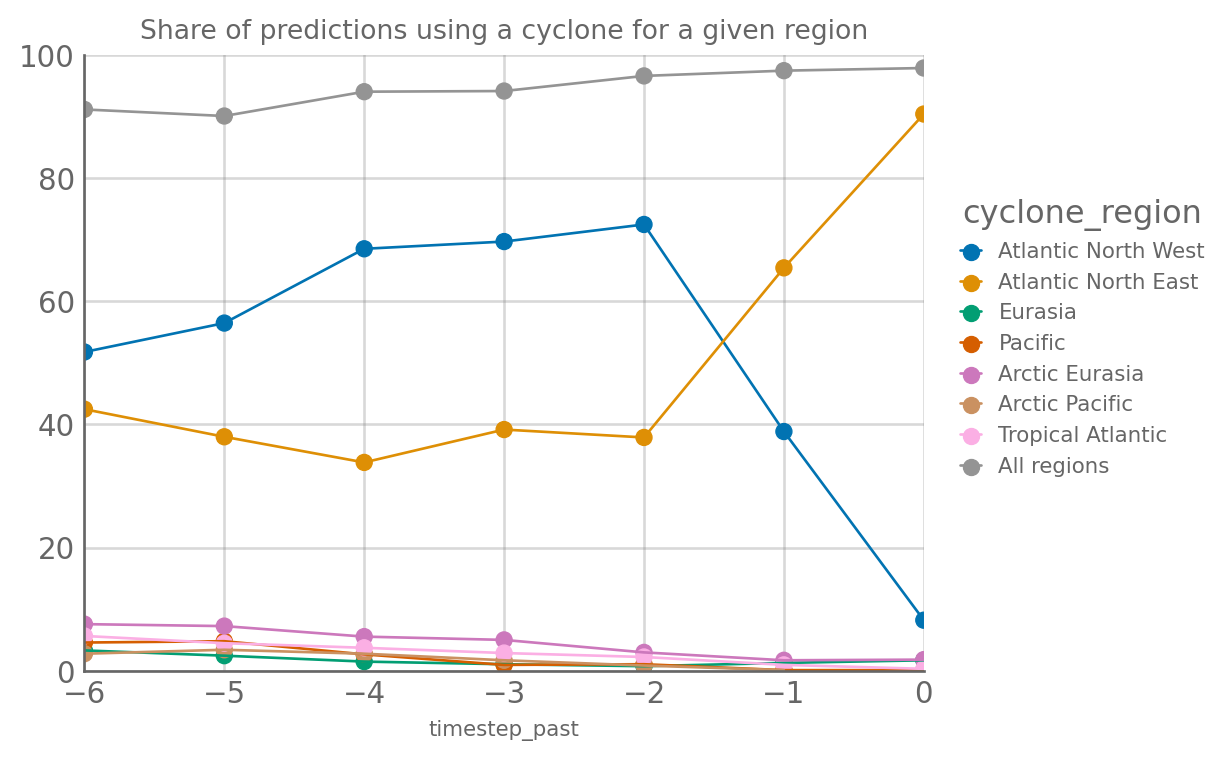

In [19]:
df_counts = gdf_cyclones.reset_index().query("blob_category=='large positive'").groupby(['time_of_event','timestep_past','cyclone_region']).cyclone_msl.count().reset_index()
df_all_counts = gdf_cyclones.reset_index().query("blob_category=='large positive'").groupby(['time_of_event','timestep_past']).cyclone_msl.count().reset_index()
df_all_counts['cyclone_region'] = 'All regions'
df_counts = pd.concat([df_counts, df_all_counts])

(so.Plot(df_counts, x='timestep_past', color='cyclone_region')
 .add(so.Line(), so.Count(), so.Norm(func=lambda x:937, percent=True))
#  .add(so.Line(linewidth=3), so.Count(), so.Norm(func=lambda x:937, percent=True), data=df_all_counts)
 .add(so.Dot(), so.Count(), so.Norm(func=lambda x:937, percent=True))
#  .facet(col='blo_category')
 .scale(color=so.Nominal(order=['Atlantic North West','Atlantic North East',
       'Eurasia', 'Pacific', 'Arctic Eurasia','Arctic Pacific', 
       'Tropical Atlantic','All regions']))

 .layout(size=(5,4))
 .limit(x=(-6,0), y=(0,100))
 .label(title='Share of predictions using a cyclone for a given region', )
  .theme(plt.style.library["robin"])
 .theme({'axes.grid':True, 'grid.color':'.5','grid.linestyle':'-', 'grid.alpha':.3})
 )

